# SIR Emulator — Full Analysis Plots
Predicted vs observed · Error heatmap · Conservation · Zone R² · Critical slowing · Bimodal · Sobol · Ensemble variance · Conformal · Intervention · ABC

In [13]:
import sys
from pathlib import Path

# Notebook CWD is experiments/mcmc-sampling/scripts/ — resolve all paths from here
NOTEBOOK_DIR = Path().resolve()          # .../experiments/mcmc-sampling/scripts
MCMC_DIR     = NOTEBOOK_DIR.parent      # .../experiments/mcmc-sampling

SCRIPTS_DIR = NOTEBOOK_DIR
MODELS_DIR  = MCMC_DIR / 'out'  / 'trained-models'
DATA_PATH   = MCMC_DIR / 'data' / 'split' / 'abm-data_split.pkl'

sys.path.insert(0, str(SCRIPTS_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import types

from step0_model import create_hybrid_mlp_model
from utils import create_dataloaders, get_device, PARAM_MINS, PARAM_MAXS

N      = 100_000
RATIO  = 58
T      = 250
t_grid = np.linspace(0, 250, T)
LOWS   = np.array([0.00025, 0.03, 0.001], dtype=np.float32)
HIGHS  = np.array([0.17,    1.0,  0.01 ], dtype=np.float32)

print(f'Scripts : {SCRIPTS_DIR}')
print(f'Models  : {MODELS_DIR}')
print(f'Data    : {DATA_PATH}')
assert MODELS_DIR.exists(), f'Models dir not found: {MODELS_DIR}'
assert DATA_PATH.exists(),  f'Data file not found: {DATA_PATH}'

device = get_device()

# ── load all replicate models ──────────────────────────────────────
def _load_models(models_dir, device, n=10):
    models = []
    for i in range(1, n + 1):
        ckpt = torch.load(models_dir / f'best_balanced_mlp_model_{i}.pt',
                          map_location=device, weights_only=False)
        config = ckpt.get('config', {
            'n_params': 3, 'n_fourier': 64, 'sigma': 1.0,
            'fusion_hidden': 128, 'latent_dim': 64, 'decoder_hidden': 64,
            'dropout': 0.3, 'n_knots': 8, 'n_timepoints': T,
            'total_population': N,
        })
        sd = ckpt['model_state_dict']
        sd.pop('temporal_decoder.t_grid', None)
        m = create_hybrid_mlp_model(config)
        m.load_state_dict(sd, strict=True)
        m.to(device).eval()
        models.append(m)
    return models

models = _load_models(MODELS_DIR, device)
print(f'Loaded {len(models)} replicate models')

# ── data loaders ──────────────────────────────────────────────────
dataloaders = create_dataloaders(str(DATA_PATH), batch_size=64)
test_loader = dataloaders['test']
val_loader  = dataloaders['val']

# ── ensemble inference ────────────────────────────────────────────
@torch.no_grad()
def run_ensemble(models, loader, device):
    pm = torch.tensor(PARAM_MINS)
    px = torch.tensor(PARAM_MAXS)
    all_p, all_t, all_params = [], [], []
    for batch in loader:
        batch = batch.to(device)
        preds = torch.stack([m(batch) for m in models])
        all_p.append(preds.cpu())
        all_t.append(batch.y.cpu())
        all_params.append(batch.params_norm.cpu() * (px - pm) + pm)
    return (torch.cat(all_p, dim=1).numpy(),
            torch.cat(all_t, dim=0).numpy(),
            torch.cat(all_params, dim=0).numpy())

print('Running test-set inference...')
test_preds, test_targets, test_params = run_ensemble(models, test_loader, device)
print('Running val-set inference...')
val_preds,  val_targets,  val_params  = run_ensemble(models, val_loader,  device)

# ── derived quantities ────────────────────────────────────────────
ens_mean = test_preds.mean(axis=0)   # (n, T, 3)
ens_std  = test_preds.std(axis=0)    # (n, T, 3)
tau   = test_params[:, 0]
gamma = test_params[:, 1]
rho   = test_params[:, 2]
R0    = (tau / gamma) * RATIO
mae_i = np.abs(ens_mean[:, :, 1] - test_targets[:, :, 1]).mean(axis=1)

print(f'Test samples : {len(test_targets)}')
print(f'R0 range     : [{R0.min():.2f}, {R0.max():.2f}]')
print(f'Mean MAE_I   : {mae_i.mean():.1f}')

Scripts : C:\Users\gmm71\OneDrive - University of Cambridge\Documents\Emulation models\abm-epidemic-emulator\experiments\mcmc-sampling\scripts
Models  : C:\Users\gmm71\OneDrive - University of Cambridge\Documents\Emulation models\abm-epidemic-emulator\experiments\mcmc-sampling\out\trained-models
Data    : C:\Users\gmm71\OneDrive - University of Cambridge\Documents\Emulation models\abm-epidemic-emulator\experiments\mcmc-sampling\data\split\abm-data_split.pkl

 Using CPU
Loaded 10 replicate models

Loading dataset : C:\Users\gmm71\OneDrive - University of Cambridge\Documents\Emulation models\abm-epidemic-emulator\experiments\mcmc-sampling\data\split\abm-data_split.pkl
  n_timepoints  : 250
  Train=2800, Val=600, Test=600
Running test-set inference...
Running val-set inference...
Test samples : 600
R0 range     : [0.03, 5.43]
Mean MAE_I   : 50.1


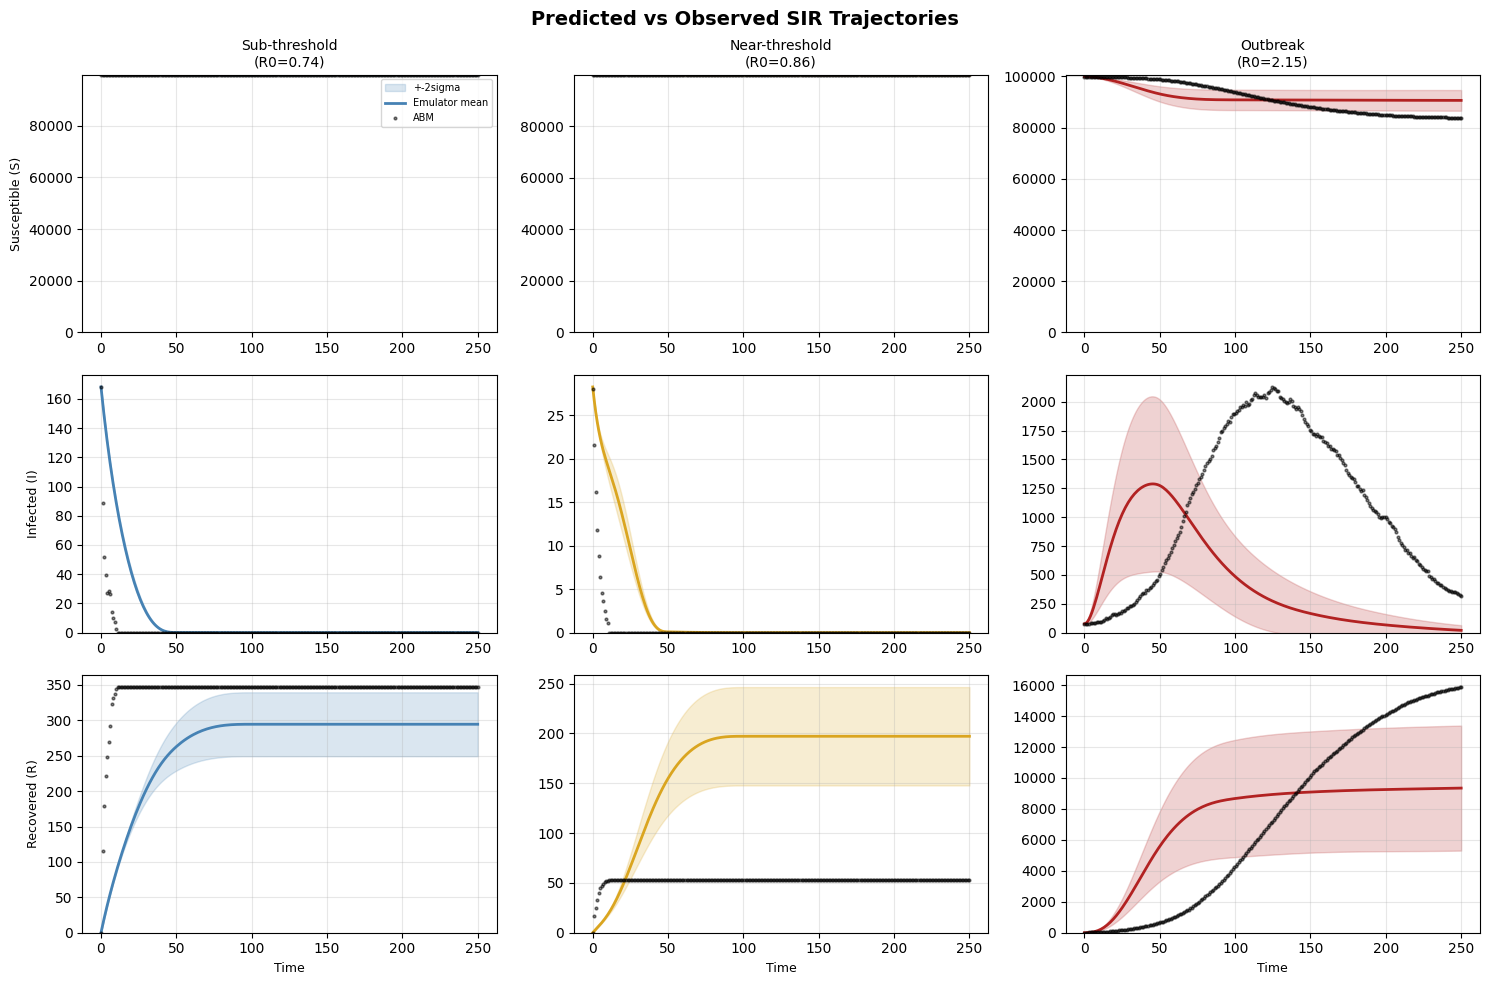

In [14]:
# ── 1. PREDICTED vs OBSERVED TRAJECTORIES ─────────────────────────
zones = [
    ('Sub-threshold',  R0 < 0.8,                      'steelblue'),
    ('Near-threshold', (R0 >= 0.8) & (R0 <= 2.0),     'goldenrod'),
    ('Outbreak',       R0 > 2.0,                       'firebrick'),
]
comp_labels = ['Susceptible (S)', 'Infected (I)', 'Recovered (R)']

np.random.seed(42)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Predicted vs Observed SIR Trajectories', fontsize=14, fontweight='bold')

for col, (zone_name, mask, color) in enumerate(zones):
    idx_pool = np.where(mask)[0]
    if len(idx_pool) == 0:
        continue
    idx = np.random.choice(idx_pool)
    for row, comp in enumerate([0, 1, 2]):
        ax = axes[row, col]
        true_c  = test_targets[idx, :, comp]
        pred_mu = ens_mean[idx, :, comp]
        pred_sd = ens_std[idx, :, comp]
        ax.fill_between(t_grid, pred_mu - 2*pred_sd, pred_mu + 2*pred_sd,
                        alpha=0.20, color=color, label='+-2sigma')
        ax.plot(t_grid, pred_mu, '-', color=color, lw=2, label='Emulator mean')
        ax.plot(t_grid, true_c,  'o', color='black', ms=2, alpha=0.5, label='ABM')
        if row == 0:
            ax.set_title(f'{zone_name}\n(R0={R0[idx]:.2f})', fontsize=10)
        if col == 0:
            ax.set_ylabel(comp_labels[comp], fontsize=9)
        if row == 2:
            ax.set_xlabel('Time', fontsize=9)
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('predicted_vs_observed.png', dpi=150, bbox_inches='tight')
plt.show()

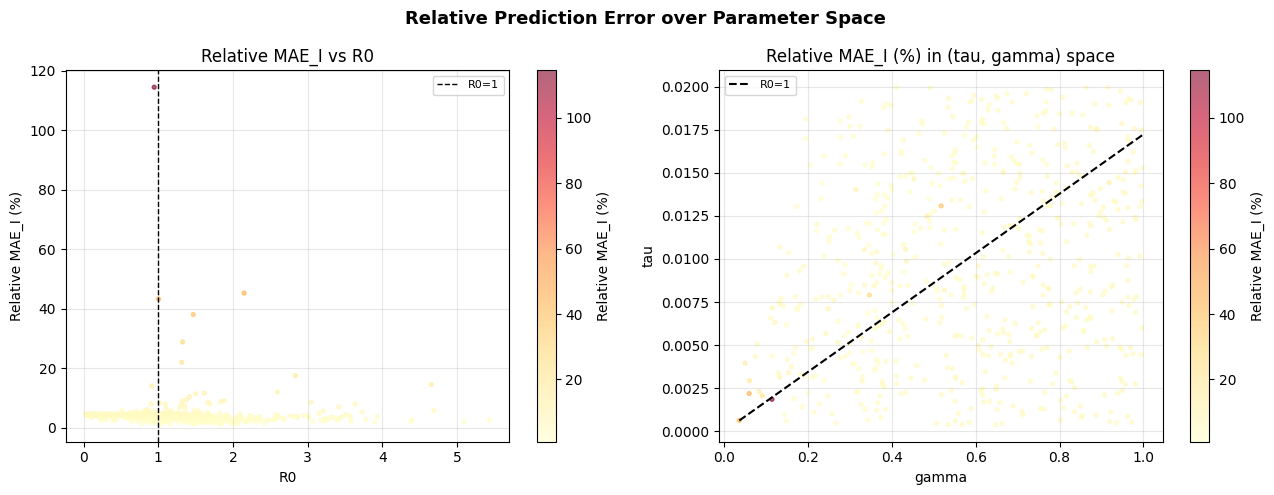

Valid samples (peak_I >= 1): 600 / 600
Mean Relative MAE_I: 4.41%


In [15]:
# ── 2. ERROR HEATMAP OVER R0 ──────────────────────────────────────
# Per-sample relative MAE_I = MAE_I / peak_I × 100  (excludes near-zero peaks)
peak_i  = test_targets[:, :, 1].max(axis=1)           # (n,)
valid   = peak_i >= 1.0
rel_mae = np.full(len(peak_i), np.nan)
rel_mae[valid] = mae_i[valid] / peak_i[valid] * 100   # (%)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Relative Prediction Error over Parameter Space', fontsize=13, fontweight='bold')

sc = axes[0].scatter(R0[valid], rel_mae[valid], c=rel_mae[valid], cmap='YlOrRd', s=8, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label='Relative MAE_I (%)')
axes[0].axvline(1.0, color='black', linestyle='--', lw=1, label='R0=1')
axes[0].set_xlabel('R0'); axes[0].set_ylabel('Relative MAE_I (%)')
axes[0].set_title('Relative MAE_I vs R0'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

sc2 = axes[1].scatter(gamma[valid], tau[valid], c=rel_mae[valid], cmap='YlOrRd', s=8, alpha=0.6)
plt.colorbar(sc2, ax=axes[1], label='Relative MAE_I (%)')
g_line = np.linspace(gamma.min(), gamma.max(), 200)
axes[1].plot(g_line, g_line / RATIO, 'k--', lw=1.5, label='R0=1')
axes[1].set_xlabel('gamma'); axes[1].set_ylabel('tau')
axes[1].set_title('Relative MAE_I (%) in (tau, gamma) space'); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_heatmap_R0.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Valid samples (peak_I >= 1): {valid.sum()} / {len(valid)}')
print(f'Mean Relative MAE_I: {rel_mae[valid].mean():.2f}%')

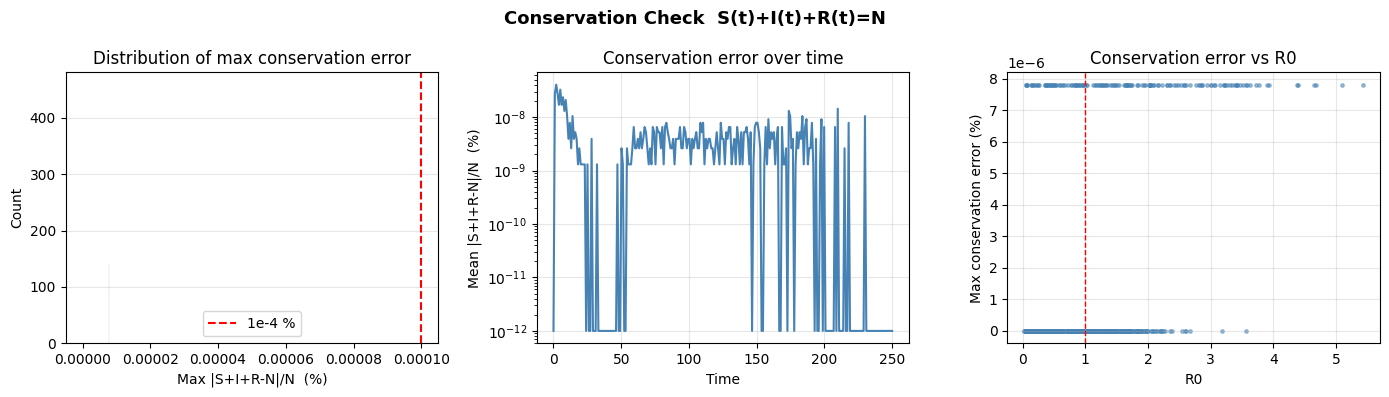

Max  conservation error: 7.81e-06 %
Mean conservation error: 1.85e-06 %


In [16]:
# ── 3. CONSERVATION VIOLATION CHECK ───────────────────────────────
# For the full model, S+I+R must equal N exactly at every timestep.
SIR_sum  = test_preds[:, :, :, 0] + test_preds[:, :, :, 1] + test_preds[:, :, :, 2]
cons_err = np.abs(SIR_sum - N) / N * 100   # (K, n, T) as percent
max_err_per_sample = cons_err.max(axis=(0, 2))  # worst case per test sample
mean_err_over_time = cons_err.mean(axis=(0, 1)) # (T,)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Conservation Check  S(t)+I(t)+R(t)=N', fontsize=13, fontweight='bold')

axes[0].hist(max_err_per_sample, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(1e-4, color='red', linestyle='--', label='1e-4 %')
axes[0].set_xlabel('Max |S+I+R-N|/N  (%)'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of max conservation error')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

axes[1].semilogy(t_grid, mean_err_over_time + 1e-12, color='steelblue')
axes[1].set_xlabel('Time'); axes[1].set_ylabel('Mean |S+I+R-N|/N  (%)')
axes[1].set_title('Conservation error over time')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(R0, max_err_per_sample, s=6, alpha=0.5, color='steelblue')
axes[2].axvline(1.0, color='red', linestyle='--', lw=1)
axes[2].set_xlabel('R0'); axes[2].set_ylabel('Max conservation error (%)')
axes[2].set_title('Conservation error vs R0')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('conservation_check.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Max  conservation error: {max_err_per_sample.max():.2e} %')
print(f'Mean conservation error: {max_err_per_sample.mean():.2e} %')

,n,R2_S,R2_I,R2_R,MAE_I
Zone,,,,,
Sub-critical (R0 < 0.5),146,0.9561,-2.1097,0.8622,22.1
Near-critical (0.5 <= R0 < 1),164,0.5797,-0.7753,0.5340,18.3
Near-outbreak (1 <= R0 < 2),210,0.8548,0.7932,0.8511,27.9
Outbreak (2 <= R0 < 5),78,0.9013,0.8545,0.9049,220.7
Major outbreak (R0 >= 5),2,0.6541,0.8928,0.7632,387.7


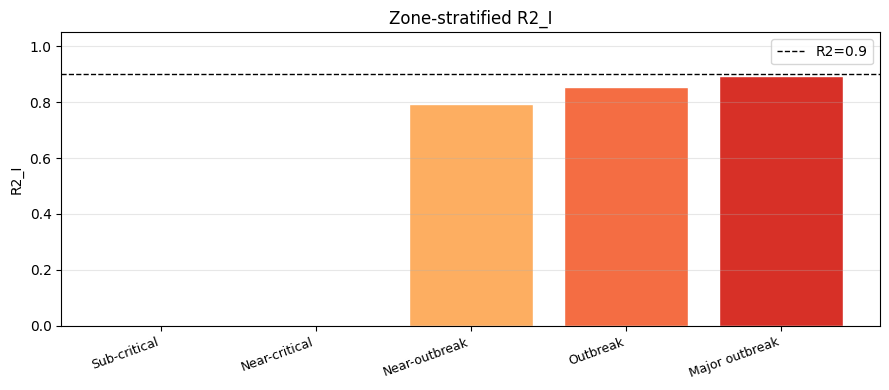

In [17]:
# ── 4. ZONE-STRATIFIED R2 TABLE ────────────────────────────────────
def _r2(pred, true):
    ss_r = np.sum((true - pred)**2)
    ss_t = np.sum((true - true.mean())**2)
    return float(1.0 - ss_r / (ss_t + 1e-8))

zone_defs = [
    ('Sub-critical  (R0 < 0.5)',        R0 < 0.5),
    ('Near-critical (0.5 <= R0 < 1)',   (R0 >= 0.5) & (R0 < 1.0)),
    ('Near-outbreak (1 <= R0 < 2)',     (R0 >= 1.0) & (R0 < 2.0)),
    ('Outbreak      (2 <= R0 < 5)',     (R0 >= 2.0) & (R0 < 5.0)),
    ('Major outbreak (R0 >= 5)',         R0 >= 5.0),
]

rows = []
for zone_name, mask in zone_defs:
    n = mask.sum()
    if n == 0:
        continue
    pz = ens_mean[mask]
    tz = test_targets[mask]
    rows.append({
        'Zone': zone_name, 'n': int(n),
        'R2_S': round(_r2(pz[:,:,0], tz[:,:,0]), 4),
        'R2_I': round(_r2(pz[:,:,1], tz[:,:,1]), 4),
        'R2_R': round(_r2(pz[:,:,2], tz[:,:,2]), 4),
        'MAE_I': round(float(np.abs(pz[:,:,1] - tz[:,:,1]).mean()), 1),
    })

df_zone = pd.DataFrame(rows).set_index('Zone')
display(df_zone)

# Bar chart
zone_r2i   = [r['R2_I']  for r in rows]
zone_names = [r['Zone'].split('(')[0].strip() for r in rows]
colors_z   = ['#4575b4','#74add1','#fdae61','#f46d43','#d73027'][:len(rows)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(zone_names)), zone_r2i, color=colors_z, edgecolor='white')
ax.set_xticks(range(len(zone_names)))
ax.set_xticklabels(zone_names, rotation=20, ha='right', fontsize=9)
ax.axhline(0.9, color='black', linestyle='--', lw=1, label='R2=0.9')
ax.set_ylabel('R2_I'); ax.set_title('Zone-stratified R2_I')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('zone_stratified_r2.png', dpi=150, bbox_inches='tight')
plt.show()

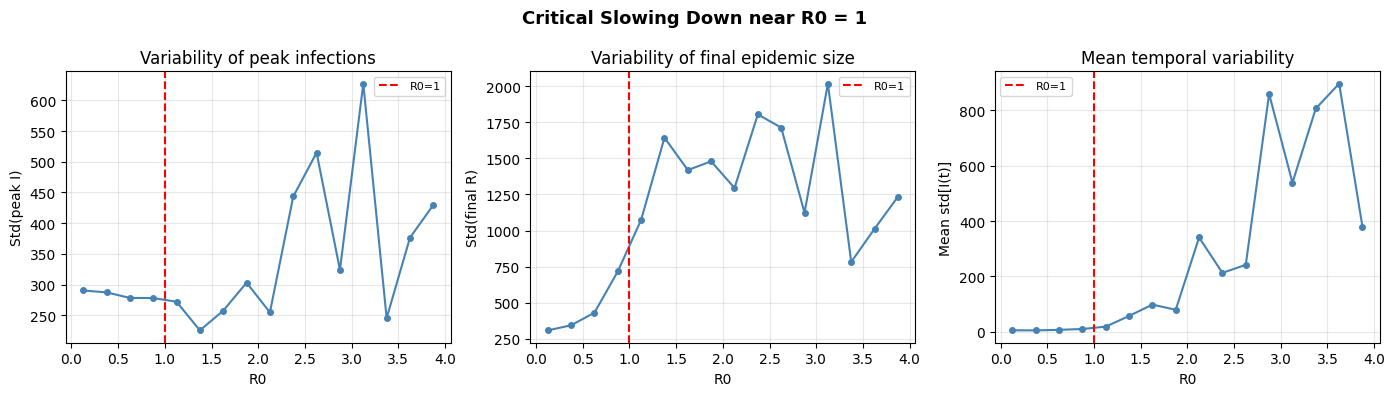

In [18]:
# ── 5. CRITICAL SLOWING DOWN ──────────────────────────────────────
# Near R0=1 the SIR system slows: trajectories become maximally variable.
bins    = np.linspace(0, 6, 25)
mids    = (bins[:-1] + bins[1:]) / 2
bin_idx = np.digitize(R0, bins) - 1

std_peak_I, std_final_R, std_traj_I = [], [], []
for b in range(len(bins) - 1):
    m = (bin_idx == b)
    if m.sum() < 3:
        std_peak_I.append(np.nan)
        std_final_R.append(np.nan)
        std_traj_I.append(np.nan)
        continue
    I_curves = test_targets[m, :, 1]
    std_peak_I.append(np.std(I_curves.max(axis=1)))
    std_final_R.append(np.std(test_targets[m, -1, 2]))
    std_traj_I.append(np.std(I_curves, axis=0).mean())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Critical Slowing Down near R0 = 1', fontsize=13, fontweight='bold')

for ax, y, ylabel, title in [
    (axes[0], std_peak_I,  'Std(peak I)',     'Variability of peak infections'),
    (axes[1], std_final_R, 'Std(final R)',    'Variability of final epidemic size'),
    (axes[2], std_traj_I,  'Mean std[I(t)]',  'Mean temporal variability'),
]:
    ax.plot(mids, y, 'o-', color='steelblue', ms=4)
    ax.axvline(1.0, color='red', linestyle='--', lw=1.5, label='R0=1')
    ax.set_xlabel('R0'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('critical_slowing_down.png', dpi=150, bbox_inches='tight')
plt.show()

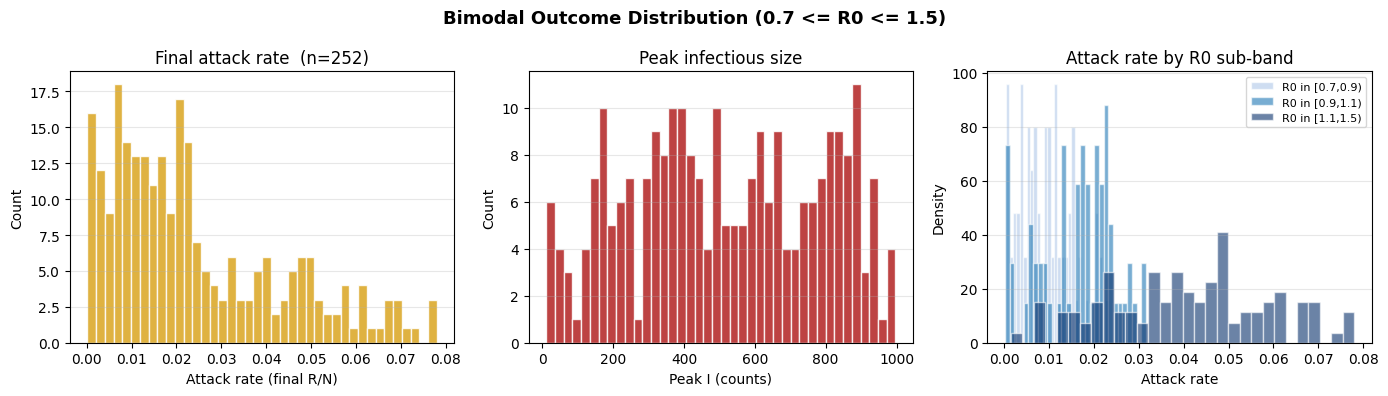

In [19]:
# ── 6. BIMODAL OUTCOME DISTRIBUTION ──────────────────────────────
# Near R0=1, finite-size SIR systems are bimodal:
# the epidemic either dies out OR causes a large outbreak.
near_mask   = (R0 >= 0.7) & (R0 <= 1.5)
attack_rate = test_targets[near_mask, -1, 2] / N

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Bimodal Outcome Distribution (0.7 <= R0 <= 1.5)', fontsize=13, fontweight='bold')

axes[0].hist(attack_rate, bins=40, color='goldenrod', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Attack rate (final R/N)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Final attack rate  (n={near_mask.sum()})')
axes[0].grid(True, alpha=0.3, axis='y')

peak_I_near = test_targets[near_mask, :, 1].max(axis=1)
axes[1].hist(peak_I_near, bins=40, color='firebrick', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Peak I (counts)'); axes[1].set_ylabel('Count')
axes[1].set_title('Peak infectious size')
axes[1].grid(True, alpha=0.3, axis='y')

for r0_lo, r0_hi, col in [
    (0.7, 0.9, '#aec7e8'),
    (0.9, 1.1, '#1f77b4'),
    (1.1, 1.5, '#08306b'),
]:
    m = (R0 >= r0_lo) & (R0 < r0_hi)
    if m.sum() > 0:
        axes[2].hist(test_targets[m, -1, 2] / N, bins=30, alpha=0.6, color=col,
                     label=f'R0 in [{r0_lo},{r0_hi})', edgecolor='white', density=True)
axes[2].set_xlabel('Attack rate'); axes[2].set_ylabel('Density')
axes[2].set_title('Attack rate by R0 sub-band')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('bimodal_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

Computing Sobol indices (may take ~30 s)...


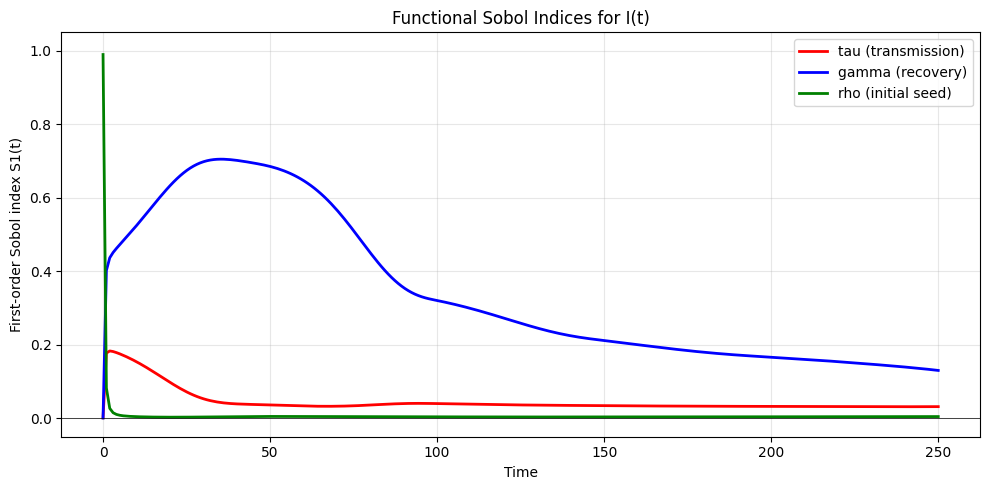

In [20]:
# ── 7. FUNCTIONAL SOBOL INDICES (time-varying) ────────────────────
# First-order Sobol index S1_k(t) = Var[E[I(t)|theta_k]] / Var[I(t)]
# Estimated by binning each parameter and computing between-bin variance.

@torch.no_grad()
def compute_sobol_indices(models, n_mc=3000, n_bins=10, seed=0):
    np.random.seed(seed)
    samples_raw  = np.random.uniform(LOWS, HIGHS, size=(n_mc, 3)).astype(np.float32)
    samples_norm = (samples_raw - LOWS) / (HIGHS - LOWS + 1e-8)
    batch = types.SimpleNamespace(
        params_norm=torch.FloatTensor(samples_norm).to(device),
        rho_raw=torch.FloatTensor(samples_raw[:, 2]).to(device),
    )
    I_mat = torch.stack([m(batch) for m in models]).mean(0).cpu().numpy()[:, :, 1]
    total_var = I_mat.var(axis=0) + 1e-8
    S1 = np.zeros((T, 3))
    for k in range(3):
        vals  = samples_raw[:, k]
        edges = np.percentile(vals, np.linspace(0, 100, n_bins + 1))
        bin_means = []
        for b in range(n_bins):
            m = (vals >= edges[b]) & (vals < edges[b + 1])
            if m.sum() > 1:
                bin_means.append(I_mat[m].mean(axis=0))
        if bin_means:
            S1[:, k] = np.var(np.stack(bin_means), axis=0) / total_var
    return S1

print('Computing Sobol indices (may take ~30 s)...')
S1 = compute_sobol_indices(models)

param_labels = ['tau (transmission)', 'gamma (recovery)', 'rho (initial seed)']
colors_s     = ['red', 'blue', 'green']

fig, ax = plt.subplots(figsize=(10, 5))
for k, (label, col) in enumerate(zip(param_labels, colors_s)):
    ax.plot(t_grid, S1[:, k], color=col, lw=2, label=label)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Time'); ax.set_ylabel('First-order Sobol index S1(t)')
ax.set_title('Functional Sobol Indices for I(t)')
ax.set_ylim(-0.05, 1.05)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sobol_indices.png', dpi=150, bbox_inches='tight')
plt.show()

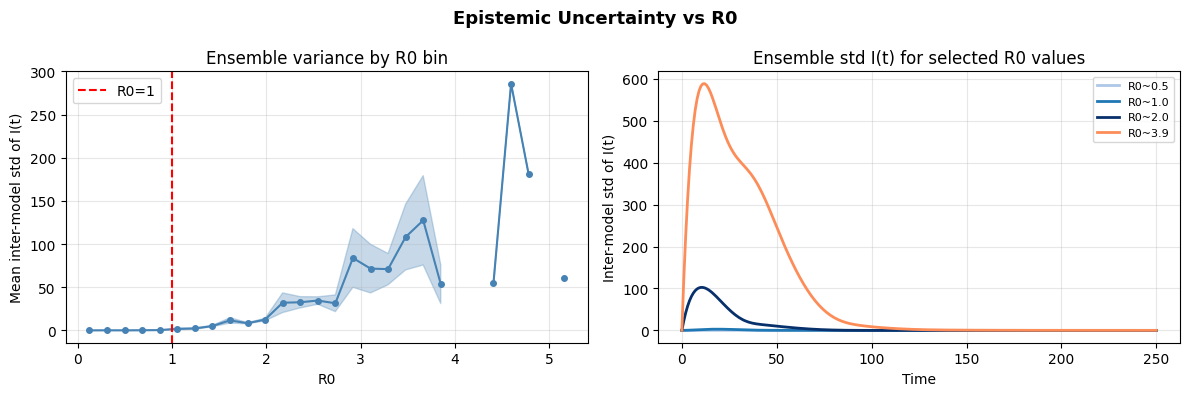

In [21]:
# ── 8. ENSEMBLE VARIANCE vs R0 ────────────────────────────────────
# Inter-model (epistemic) uncertainty as a function of R0.
std_I_sample = ens_std[:, :, 1].mean(axis=1)   # mean over time per sample

bins_r = np.linspace(R0.min(), min(R0.max(), 8), 30)
mids_r = (bins_r[:-1] + bins_r[1:]) / 2
bidx_r = np.digitize(R0, bins_r) - 1

mean_std = np.array([
    std_I_sample[bidx_r == b].mean() if (bidx_r == b).sum() > 0 else np.nan
    for b in range(len(bins_r) - 1)
])
sem_std = np.array([
    stats.sem(std_I_sample[bidx_r == b]) if (bidx_r == b).sum() > 1 else 0.0
    for b in range(len(bins_r) - 1)
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Epistemic Uncertainty vs R0', fontsize=13, fontweight='bold')

axes[0].fill_between(mids_r,
                     mean_std - sem_std, mean_std + sem_std,
                     alpha=0.3, color='steelblue')
axes[0].plot(mids_r, mean_std, '-o', color='steelblue', ms=4)
axes[0].axvline(1.0, color='red', linestyle='--', lw=1.5, label='R0=1')
axes[0].set_xlabel('R0'); axes[0].set_ylabel('Mean inter-model std of I(t)')
axes[0].set_title('Ensemble variance by R0 bin')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for r0_target, col in [(0.5, '#aec7e8'), (1.0, '#1f77b4'), (2.0, '#08306b'), (4.0, '#fc8d59')]:
    idx_c = np.argmin(np.abs(R0 - r0_target))
    axes[1].plot(t_grid, ens_std[idx_c, :, 1], color=col,
                 label=f'R0~{R0[idx_c]:.1f}', lw=2)
axes[1].set_xlabel('Time'); axes[1].set_ylabel('Inter-model std of I(t)')
axes[1].set_title('Ensemble std I(t) for selected R0 values')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ensemble_variance_R0.png', dpi=150, bbox_inches='tight')
plt.show()

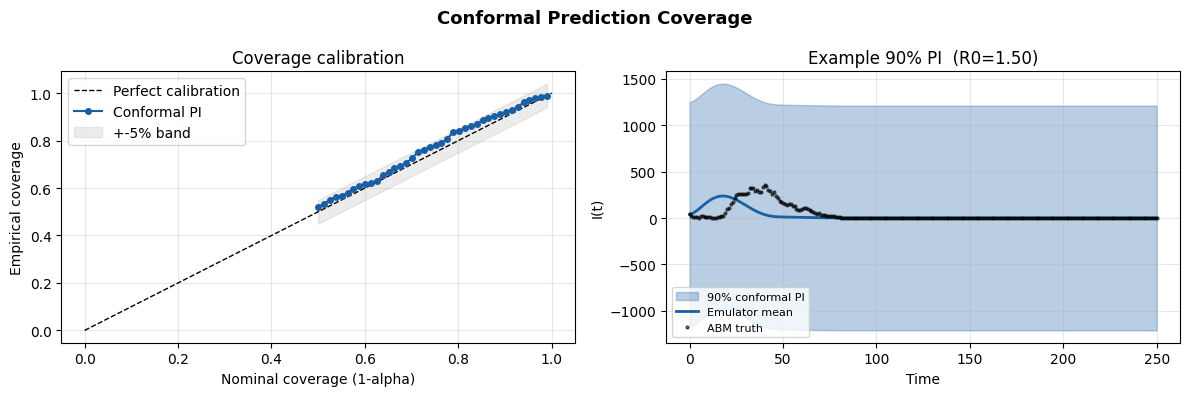

Calibration set size: 600   90%-quantile score: 1209.4


In [22]:
# ── 9. CONFORMAL PREDICTION COVERAGE ──────────────────────────────
# Val set = calibration; test set = evaluation.
# Nonconformity score: max_t |I_true(t) - I_pred_mean(t)|
val_mean_I  = val_preds.mean(axis=0)[:, :, 1]   # (n_val, T)
cal_scores  = np.abs(val_mean_I - val_targets[:, :, 1]).max(axis=1)
test_mean_I = ens_mean[:, :, 1]
true_I_test = test_targets[:, :, 1]
n_cal       = len(cal_scores)

alphas = np.linspace(0.01, 0.50, 40)
empirical_cov = []
for alpha in alphas:
    level = min(np.ceil((1 - alpha) * (n_cal + 1)) / n_cal, 1.0)
    q = np.quantile(cal_scores, level)
    covered = ((true_I_test >= test_mean_I - q) &
               (true_I_test <= test_mean_I + q)).all(axis=1).mean()
    empirical_cov.append(float(covered))
empirical_cov = np.array(empirical_cov)
nominal_cov   = 1 - alphas

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Conformal Prediction Coverage', fontsize=13, fontweight='bold')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
axes[0].plot(nominal_cov, empirical_cov, 'o-', color='#185FA5', ms=4, label='Conformal PI')
axes[0].fill_between(nominal_cov, nominal_cov - 0.05, nominal_cov + 0.05,
                     alpha=0.15, color='gray', label='+-5% band')
axes[0].set_xlabel('Nominal coverage (1-alpha)'); axes[0].set_ylabel('Empirical coverage')
axes[0].set_title('Coverage calibration')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

q_90     = np.quantile(cal_scores, min(np.ceil(0.90 * (n_cal + 1)) / n_cal, 1.0))
idx_show = np.argmin(np.abs(R0 - 1.5))
axes[1].fill_between(t_grid,
                     test_mean_I[idx_show] - q_90,
                     test_mean_I[idx_show] + q_90,
                     alpha=0.3, color='#185FA5', label='90% conformal PI')
axes[1].plot(t_grid, test_mean_I[idx_show], '-', color='#185FA5', lw=2, label='Emulator mean')
axes[1].plot(t_grid, true_I_test[idx_show], 'o', color='black', ms=2, alpha=0.6, label='ABM truth')
axes[1].set_xlabel('Time'); axes[1].set_ylabel('I(t)')
axes[1].set_title(f'Example 90% PI  (R0={R0[idx_show]:.2f})')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('conformal_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Calibration set size: {n_cal}   90%-quantile score: {q_90:.1f}')

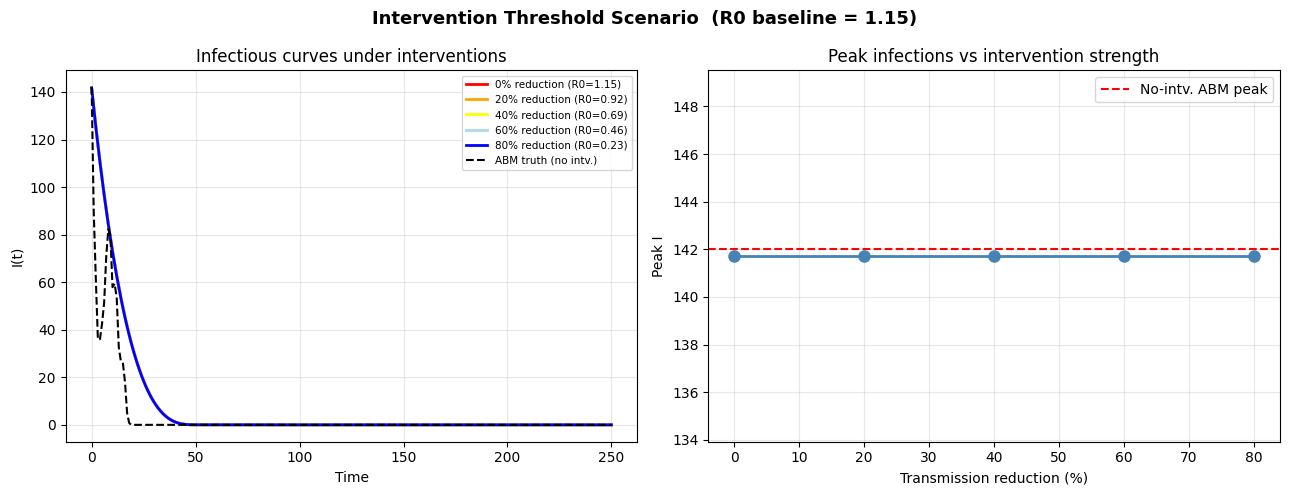

In [23]:
# ── 10. INTERVENTION THRESHOLD SCENARIO ───────────────────────────
# From a baseline near-threshold scenario, reduce tau by 0-80%
# and show the emulator's predicted I(t) and peak I.

ref_mask = (R0 >= 1.05) & (R0 <= 1.3)
if ref_mask.sum() == 0:
    ref_mask = (R0 >= 1.0) & (R0 <= 2.0)
ref_idx   = np.where(ref_mask)[0][0]
tau_ref   = float(tau[ref_idx])
gamma_ref = float(gamma[ref_idx])
rho_ref   = float(rho[ref_idx])
R0_ref    = R0[ref_idx]

reductions  = [0.0, 0.20, 0.40, 0.60, 0.80]
colors_intv = ['red', 'orange', 'yellow', 'lightblue', 'blue']

def predict_intv(tau_new, gamma_val, rho_val):
    p_raw  = np.array([[tau_new, gamma_val, rho_val]], dtype=np.float32)
    p_norm = (p_raw - LOWS) / (HIGHS - LOWS + 1e-8)
    batch  = types.SimpleNamespace(
        params_norm=torch.FloatTensor(p_norm).to(device),
        rho_raw=torch.FloatTensor([rho_val]).to(device),
    )
    with torch.no_grad():
        return torch.stack([m(batch) for m in models]).mean(0).cpu().numpy()[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Intervention Threshold Scenario  (R0 baseline = {R0_ref:.2f})',
             fontsize=13, fontweight='bold')

peak_Is = []
for red, col in zip(reductions, colors_intv):
    tau_new = tau_ref * (1 - red)
    R0_new  = (tau_new / gamma_ref) * RATIO
    pred    = predict_intv(tau_new, gamma_ref, rho_ref)
    I_curve = pred[:, 1]
    peak_Is.append(I_curve.max())
    axes[0].plot(t_grid, I_curve, color=col, lw=2,
                 label=f'{int(red*100)}% reduction (R0={R0_new:.2f})')

axes[0].plot(t_grid, test_targets[ref_idx, :, 1], 'k--', lw=1.5, label='ABM truth (no intv.)')
axes[0].set_xlabel('Time'); axes[0].set_ylabel('I(t)')
axes[0].set_title('Infectious curves under interventions')
axes[0].legend(fontsize=7.5); axes[0].grid(True, alpha=0.3)

axes[1].plot([r * 100 for r in reductions], peak_Is, 'o-', color='steelblue', ms=8, lw=2)
axes[1].axhline(test_targets[ref_idx, :, 1].max(), color='red', linestyle='--',
                label='No-intv. ABM peak')
axes[1].set_xlabel('Transmission reduction (%)')
axes[1].set_ylabel('Peak I')
axes[1].set_title('Peak infections vs intervention strength')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('intervention_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

Pseudo-observed: tau=0.0115, gamma=0.317, rho=0.0009, R0=2.10
Accepted 1000 / 50000  (eps=0.0563)


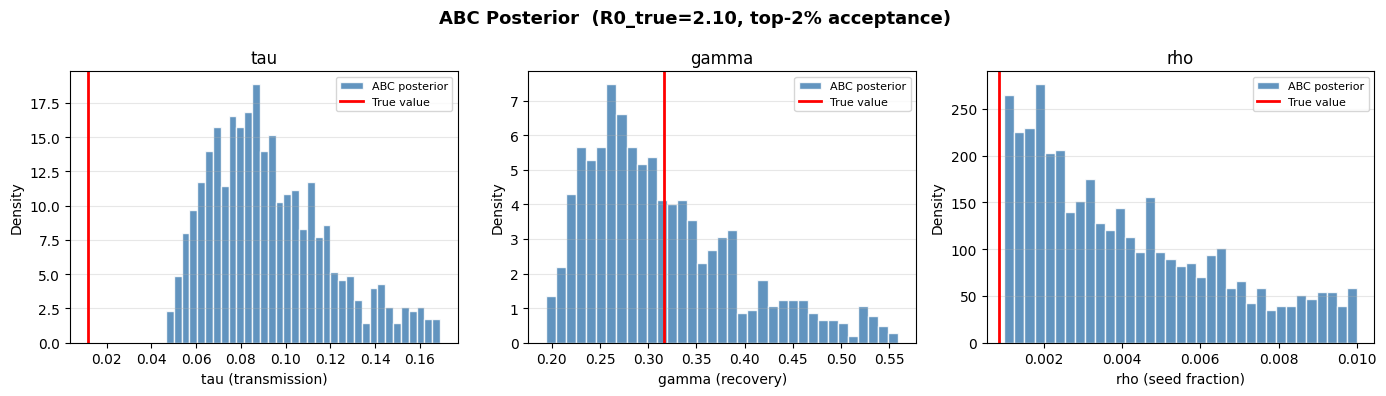

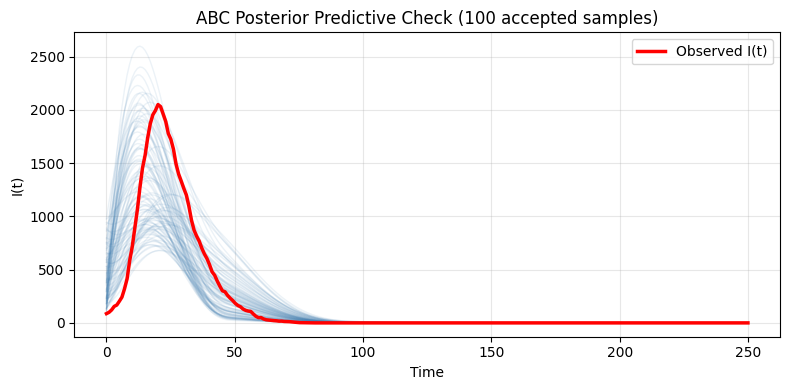

In [24]:
# ── 11. ABC POSTERIOR INFERENCE ────────────────────────────────────
# Given a pseudo-observed trajectory, infer (tau, gamma, rho)
# using rejection ABC with the emulator as the forward model.

obs_idx    = np.where(R0 > 1.5)[0][10]
I_obs      = test_targets[obs_idx, :, 1]
true_theta = test_params[obs_idx]
R0_obs     = R0[obs_idx]
print(f'Pseudo-observed: tau={true_theta[0]:.4f}, gamma={true_theta[1]:.3f}, '
      f'rho={true_theta[2]:.4f}, R0={R0_obs:.2f}')

N_abc        = 50_000
eps_quantile = 0.02    # accept top 2%
batch_size   = 512

np.random.seed(7)
samples_raw  = np.random.uniform(LOWS, HIGHS, size=(N_abc, 3)).astype(np.float32)
samples_norm = (samples_raw - LOWS) / (HIGHS - LOWS + 1e-8)

all_I_pred = []
for start in range(0, N_abc, batch_size):
    end   = min(start + batch_size, N_abc)
    batch = types.SimpleNamespace(
        params_norm=torch.FloatTensor(samples_norm[start:end]).to(device),
        rho_raw=torch.FloatTensor(samples_raw[start:end, 2]).to(device),
    )
    with torch.no_grad():
        p = torch.stack([m(batch) for m in models]).mean(0).cpu().numpy()
    all_I_pred.append(p[:, :, 1])

I_pred_abc = np.concatenate(all_I_pred, axis=0)
distances  = np.abs(I_pred_abc - I_obs[None, :]).mean(axis=1) / (I_obs.max() + 1)
eps        = np.quantile(distances, eps_quantile)
accepted   = samples_raw[distances <= eps]
print(f'Accepted {len(accepted)} / {N_abc}  (eps={eps:.4f})')

param_labels_abc = ['tau (transmission)', 'gamma (recovery)', 'rho (seed fraction)']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'ABC Posterior  (R0_true={R0_obs:.2f}, top-{int(eps_quantile*100)}% acceptance)',
             fontsize=13, fontweight='bold')

for k, (ax, label) in enumerate(zip(axes, param_labels_abc)):
    ax.hist(accepted[:, k], bins=35, density=True, color='steelblue',
            edgecolor='white', alpha=0.85, label='ABC posterior')
    ax.axvline(true_theta[k], color='red', lw=2, label='True value')
    ax.set_xlabel(label); ax.set_ylabel('Density')
    ax.set_title(label.split(' ')[0])
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('abc_posterior.png', dpi=150, bbox_inches='tight')
plt.show()

# Posterior predictive check
fig, ax = plt.subplots(figsize=(8, 4))
for i in range(min(100, len(accepted))):
    p_raw  = np.array([[accepted[i,0], accepted[i,1], accepted[i,2]]], dtype=np.float32)
    p_norm = (p_raw - LOWS) / (HIGHS - LOWS + 1e-8)
    batch  = types.SimpleNamespace(
        params_norm=torch.FloatTensor(p_norm).to(device),
        rho_raw=torch.FloatTensor([accepted[i, 2]]).to(device),
    )
    with torch.no_grad():
        pred = torch.stack([m(batch) for m in models]).mean(0).cpu().numpy()
    ax.plot(t_grid, pred[0, :, 1], alpha=0.1, color='steelblue', lw=1)
ax.plot(t_grid, I_obs, 'r-', lw=2.5, label='Observed I(t)')
ax.set_xlabel('Time'); ax.set_ylabel('I(t)')
ax.set_title('ABC Posterior Predictive Check (100 accepted samples)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('abc_posterior_predictive.png', dpi=150, bbox_inches='tight')
plt.show()